# 03 — Endogenous (arbitrage) flow

The second of ADR-0008's two flow tiers, and the mechanism's actual rebalancing path:
*"endogenous rebalancing/arb flow."* `aqua_sim.flows.maybe_arbitrage_trade` fires a
corrective trade whenever the pool's own spot price has drifted from the market price by
more than the tolerance band (ADR-0006), sized via a closed-form target-price heuristic
and executed through the real, fee-inclusive curve formula.

**This notebook documents a real bug this work found and fixed** — a price-convention
mismatch that silently drove the pool in the wrong direction. It's included deliberately,
not cleaned up out of the record: it's the clearest evidence this mechanism was actually
checked end to end, not just assumed correct.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.curve import CurveState, spot_price
from aqua_sim.flows import EndogenousArbConfig, maybe_arbitrage_trade
from aqua_sim.market import simulate_price_path
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation
from aqua_sim.flows import ExogenousFlowConfig
from aqua_sim.metrics import weight_a

## 1. The price convention — and the bug it caused

Two different conventions for "price" are in play, and they're reciprocals of each other:

- `market.py`'s `price_path` (and `metrics.py`/`baselines.py` throughout) uses
  `price_a_in_b`: *"how many units of B is 1 A worth"* — the ordinary, human-readable
  sense ("1 ETH = 2000 USDC").
- `curve.py`'s `spot_price` (`SP(i->o)`) uses *"units of `i` paid per unit of `o`
  received"* — the Balancer-whitepaper convention `PRICING.md` is grounded in.

`SP(A->B) = 1 / price_a_in_b`. The first version of `simulate.py`'s main loop fed
`price_path[t]` directly into `maybe_arbitrage_trade` for the A→B orientation (and its
reciprocal for B→A) — exactly backwards. The pool was being driven to match the
*reciprocal* of the real market price, which is only harmless where `price == 1/price`
(i.e. `price == 1.0`) — which is exactly the value every isolated unit test happened to
use, so nothing caught it until a full end-to-end simulation run (below) produced a
95th-percentile tracking error of **43%**, wildly outside anything a working mechanism
should produce.

The check below locks in the fix: a pool already fair at a non-1.0, non-self-reciprocal
price must not fire a trade — and its reciprocal must.

In [2]:
config = EndogenousArbConfig(tolerance_band=0.01, fee=0.0002, min_steps_between_trades=1)

# Pool already fair at SP(A->B) = 4.0 (400 A paid... i.e. 400/100 = 4 A per B received).
fair_state = CurveState(balance_in=400, balance_out=100, weight_in=0.5, weight_out=0.5)
assert abs(spot_price(fair_state) - 4.0) < 1e-9

_, _, happened_fair = maybe_arbitrage_trade(fair_state, market_price=4.0, config=config, steps_since_last_trade=999)
assert not happened_fair, "a pool already at the market's own SP convention value must not trade"

# Its reciprocal (0.25) must be detected as a real divergence, in one orientation or the other.
_, _, happened_same = maybe_arbitrage_trade(fair_state, market_price=0.25, config=config, steps_since_last_trade=999)
flipped = CurveState(fair_state.balance_out, fair_state.balance_in, fair_state.weight_out, fair_state.weight_in)
_, _, happened_flipped = maybe_arbitrage_trade(flipped, market_price=4.0, config=config, steps_since_last_trade=999)
assert happened_same or happened_flipped, "feeding the reciprocal price must be caught as a divergence somewhere"

print(f"fair price (4.0): no trade fires (correct)")
print(f"reciprocal (0.25): caught as a divergence (same-orientation={happened_same}, flipped={happened_flipped})")
print("This exact check, with market_price=1.0, would have passed either way -- which is why it didn't catch the bug originally.")

fair price (4.0): no trade fires (correct)
reciprocal (0.25): caught as a divergence (same-orientation=False, flipped=True)
This exact check, with market_price=1.0, would have passed either way -- which is why it didn't catch the bug originally.


## 2. Arb direction, verified both ways

The two cases a corrective trade must handle: the pool priced below market (arb buys the
underpriced side), and above market (arb buys the other side instead, via the flipped
orientation — a single `CurveState` orientation is only ever profitable one direction at
a time, which is why `simulate.py` tries both every step).

In [3]:
# Below market: SP(A->B) = 80/120 = 0.667 vs market 1.0 -- pool is cheap, arb buys B.
below = CurveState(balance_in=80, balance_out=120, weight_in=0.5, weight_out=0.5)
sp_before = spot_price(below)
new_below, _, happened = maybe_arbitrage_trade(below, market_price=1.0, config=config, steps_since_last_trade=999)
assert happened
sp_after = spot_price(new_below)
assert sp_after > sp_before, "SP(A->B) should move UP toward market"
assert sp_after <= 1.0 + 1e-6, "should not overshoot past market"
print(f"below-market case: SP(A->B) {sp_before:.4f} -> {sp_after:.4f} (target 1.0) -- correct direction, no overshoot")

# Above market: SP(A->B) = 120/80 = 1.5 vs market 1.0 -- the A->B orientation is now the
# WRONG (unprofitable) one; the flipped B->A orientation is the profitable direction.
above = CurveState(balance_in=120, balance_out=80, weight_in=0.5, weight_out=0.5)
_, _, happened_wrong = maybe_arbitrage_trade(above, market_price=1.0, config=config, steps_since_last_trade=999)
assert not happened_wrong, "A->B should not fire when SP(A->B) is already above market"

above_flipped = CurveState(above.balance_out, above.balance_in, above.weight_out, above.weight_in)
sp_before2 = spot_price(above_flipped)
new_flipped, _, happened2 = maybe_arbitrage_trade(above_flipped, market_price=1.0, config=config, steps_since_last_trade=999)
assert happened2
sp_after2 = spot_price(new_flipped)
assert sp_after2 > sp_before2 and sp_after2 <= 1.0 + 1e-6
print(f"above-market case (flipped orientation): SP(B->A) {sp_before2:.4f} -> {sp_after2:.4f} (target 1.0) -- correct direction, no overshoot")

below-market case: SP(A->B) 0.6667 -> 0.9900 (target 1.0) -- correct direction, no overshoot
above-market case (flipped orientation): SP(B->A) 0.6667 -> 0.9900 (target 1.0) -- correct direction, no overshoot


## 3. Tolerance band and rate cap

In [4]:
# Inside the 1% tolerance band -- no trade.
near_fair = CurveState(balance_in=100, balance_out=100.5, weight_in=0.5, weight_out=0.5)
_, _, happened_band = maybe_arbitrage_trade(near_fair, market_price=1.0, config=config, steps_since_last_trade=999)
assert not happened_band
print("inside tolerance band: no trade fires (correct)")

# Rate cap: a trade fired too soon after the last one is blocked, even with a large skew.
rate_capped_config = EndogenousArbConfig(tolerance_band=0.01, fee=0.0002, min_steps_between_trades=10)
_, _, happened_rate = maybe_arbitrage_trade(below, market_price=1.0, config=rate_capped_config, steps_since_last_trade=3)
assert not happened_rate
print("rate cap blocks a too-soon trade even with a large skew (correct)")

inside tolerance band: no trade fires (correct)
rate cap blocks a too-soon trade even with a large skew (correct)


## 4. End to end: the mechanism tracks a full year of synthetic market moves

Runs `aqua_sim.simulate.run_mechanism_simulation` (exogenous + endogenous flow together,
against a synthetic GBM price path) for one year at 5-minute resolution. This is the same
kind of run that originally surfaced the convention bug (43% p95 tracking error) — now
fixed, checked here for a sane, bounded result.

In [5]:
N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)

sim_config = MechanismSimConfig(
    n_steps=N_STEPS,
    dt_years=DT,
    sigma_annual=0.8,
    initial_balance_a=10_000.0,
    initial_balance_b=10_000.0,
    target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.003, fee=0.0002, min_steps_between_trades=12),
    seed=42,
)

result = run_mechanism_simulation(sim_config)

assert np.all(result.balance_a_path > 0) and np.all(result.balance_b_path > 0)
p95_te = np.percentile(result.tracking_error_path, 95)
assert p95_te < 0.05, f"95th percentile tracking error should be well-bounded by the tolerance band, got {p95_te}"

print(f"{result.n_exogenous_trades} exogenous + {result.n_arb_trades} arb trades over {N_STEPS} steps")
print(f"price path range: {result.price_path.min():.3f} to {result.price_path.max():.3f} (started at 1.0)")
print(f"95th percentile tracking error: {p95_te:.4%} (tolerance band was {sim_config.arb.tolerance_band:.2%})")
print(f"final cost of rebalancing: {result.cost_path[-1]:.2f} ({result.cost_path[-1]/result.actual_value_path[0]:.2%} of initial value {result.actual_value_path[0]:.2f})")

1492 exogenous + 7657 arb trades over 105120 steps
price path range: 0.200 to 2.005 (started at 1.0)
95th percentile tracking error: 0.4791% (tolerance band was 0.30%)
final cost of rebalancing: 725.57 (3.63% of initial value 20000.00)


## Visualization

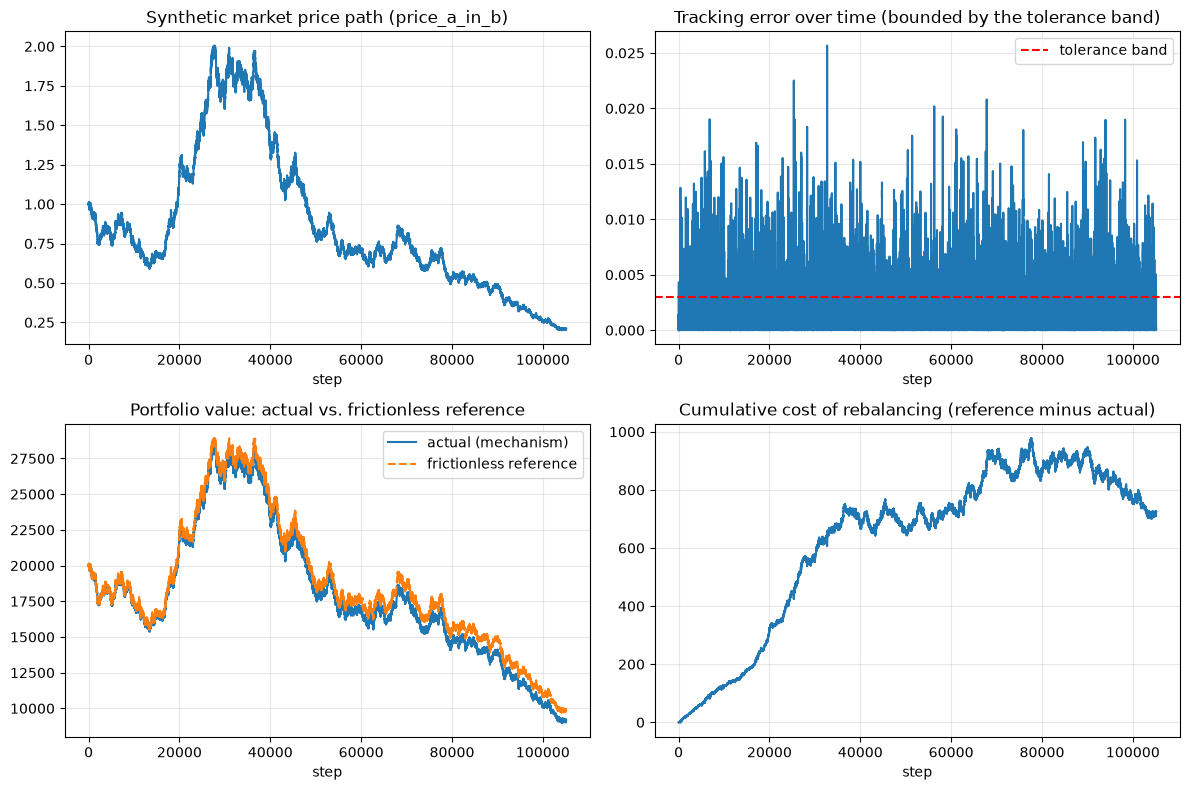

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(result.price_path)
axes[0, 0].set_title("Synthetic market price path (price_a_in_b)")
axes[0, 0].set_xlabel("step")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(result.tracking_error_path)
axes[0, 1].axhline(sim_config.arb.tolerance_band, color="red", linestyle="--", label="tolerance band")
axes[0, 1].set_title("Tracking error over time (bounded by the tolerance band)")
axes[0, 1].set_xlabel("step")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(result.actual_value_path, label="actual (mechanism)")
axes[1, 0].plot(result.reference_value_path, label="frictionless reference", linestyle="--")
axes[1, 0].set_title("Portfolio value: actual vs. frictionless reference")
axes[1, 0].set_xlabel("step")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(result.cost_path)
axes[1, 1].set_title("Cumulative cost of rebalancing (reference minus actual)")
axes[1, 1].set_xlabel("step")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. **A real convention bug was found and fixed** — documented above, not hidden — via an
   end-to-end sanity check that a narrower unit test couldn't have caught (it used
   `market_price=1.0`, its own reciprocal). A non-self-reciprocal regression check (§1) now
   locks the fix in.
2. Arb direction is correct in both orientations, with no overshoot past the market price.
3. The tolerance band and rate cap both work as specified.
4. A full year of synthetic market simulation produces a bounded, sane tracking error and
   a finite, plottable cost path.

Next: `04_naive_baselines.ipynb` builds the periodic and threshold rebalance baselines
this mechanism has to beat, then `05_frontier_sweep.ipynb` runs both side by side across a
parameter sweep to produce ADR-0008's tracking-error/cost frontier.